In [7]:
from goodrich.ch09.unsorted_priority_queue import *
from goodrich.ch08.binary_tree import *
from goodrich.ch06.array_queue import *
from goodrich.ch08.linked_binary_tree import LinkedBinaryTree
from goodrich.exceptions import Empty

In [ ]:
class UnsortedPriorityQueue1():
    def __init__(self):
        self._data = []

    def is_empty(self):
        return len(self._data) == 0

    def add(self, key, value):
        self._data.append((key, value))

    def min(self):
        if self.is_empty():
            raise ValueError("Queue is empty")
        return min(self._data)

    def remove_min(self):
        if self.is_empty():
            raise ValueError("Queue is empty")
        return self._data.pop(self._data.index(self.min()))

In [ ]:
class QueuePQ:
    '''Queue implementado con una cola de prioridad'''
    def __init__(self):
        self.data = UnsortedPriorityQueue()
        self.key = 0

    def __len__(self):
        return len(self.data)

    def is_empty(self):
        return self.data.is_empty()

    def enqueue(self, e):
        self.data.add(self.key, e)
        self.key += 1

    def dequeue(self):
        if self.is_empty():
            raise Empty('Queue is empty')
        return self.data.remove_min()[1]

    def first(self):
        if self.is_empty():
            raise Empty('Queue is empty')
        return self.data.min()[1]

In [ ]:
class StackPQ():
    def __init__(self):
        self.data = UnsortedPriorityQueue()
        self.key = 0
        
    def push(self, e):
        self.data.add(self.key, e)
        self.key -= 1 # [-1, -2, -3, ...]

    def top(self):
        return self.data.min()[1]
    
    def pop(self):  
        return self.data.remove_min()[1] 

---

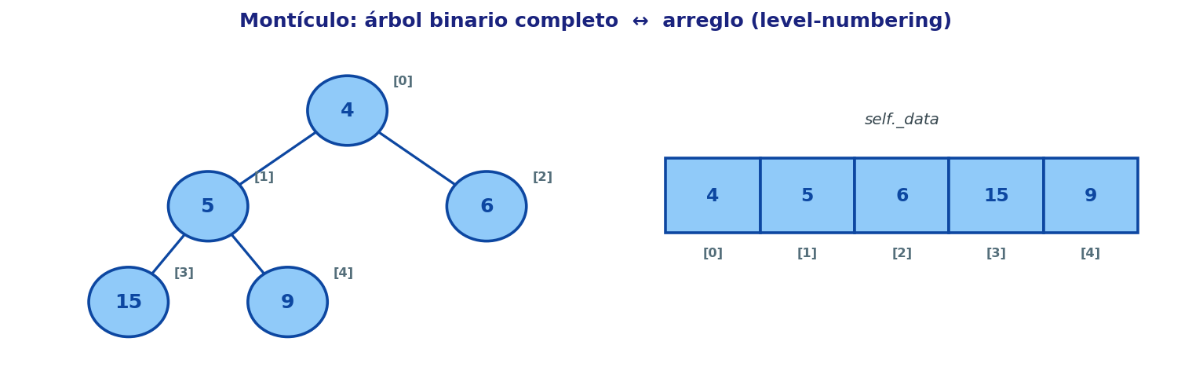

In [9]:
# Binary tree a lista (BFS)

from collections import deque

def por_niveles(tree):
    lista = []

    if tree.is_empty():
        return lista

    cola = deque([tree.root()])

    while cola:
        posicion = cola.popleft()
        lista.append(posicion.element())

        hijo_izquierdo = tree.left(posicion)
        hijo_derecho = tree.right(posicion)

        if hijo_izquierdo is not None:
            cola.append(hijo_izquierdo)

        if hijo_derecho is not None:
            cola.append(hijo_derecho)

    return lista

In [10]:
arbol = LinkedBinaryTree()
raiz = arbol._add_root(4)
nodo_5 = arbol._add_left(raiz, 5)
arbol._add_right(raiz, 6)
arbol._add_left(nodo_5, 15)
arbol._add_right(nodo_5, 9)

lista = por_niveles(arbol)
print(lista)

[4, 5, 6, 15, 9]


In [12]:
# De lista a binary tree (BFS)

def lista_a_arbol(lista):
    arbol = LinkedBinaryTree()

    if not lista or lista[0] is None:
        return arbol

    posiciones = {0: arbol._add_root(lista[0])}

    for indice, elemento in enumerate(lista):
        if indice == 0 or elemento is None:
            continue

        indice_padre = (indice - 1) // 2
        padre = posiciones.get(indice_padre)

        if padre is None:
            raise ValueError(
                f'El elemento en el indice {indice} no tiene un padre valido'
            )

        if indice % 2 == 1:
            posiciones[indice] = arbol._add_left(padre, elemento)
        else:
            posiciones[indice] = arbol._add_right(padre, elemento)

    return arbol

In [13]:
lista = [4, 5, 6, 15, 9]
arbol = lista_a_arbol(lista)

print(por_niveles(arbol))

[4, 5, 6, 15, 9]


In [15]:
lista_con_hueco = [4, 5, 6, None, 9]
arbol = lista_a_arbol(lista_con_hueco)
print(por_niveles(arbol))

[4, 5, 6, 9]
